### **Build a Simple ChatBot with LangGraph**

In [100]:
from typing import TypedDict
from typing_extensions import Annotated
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages

In [101]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function is a 'REDUCER',
    # The annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder= StateGraph(State)
graph_builder

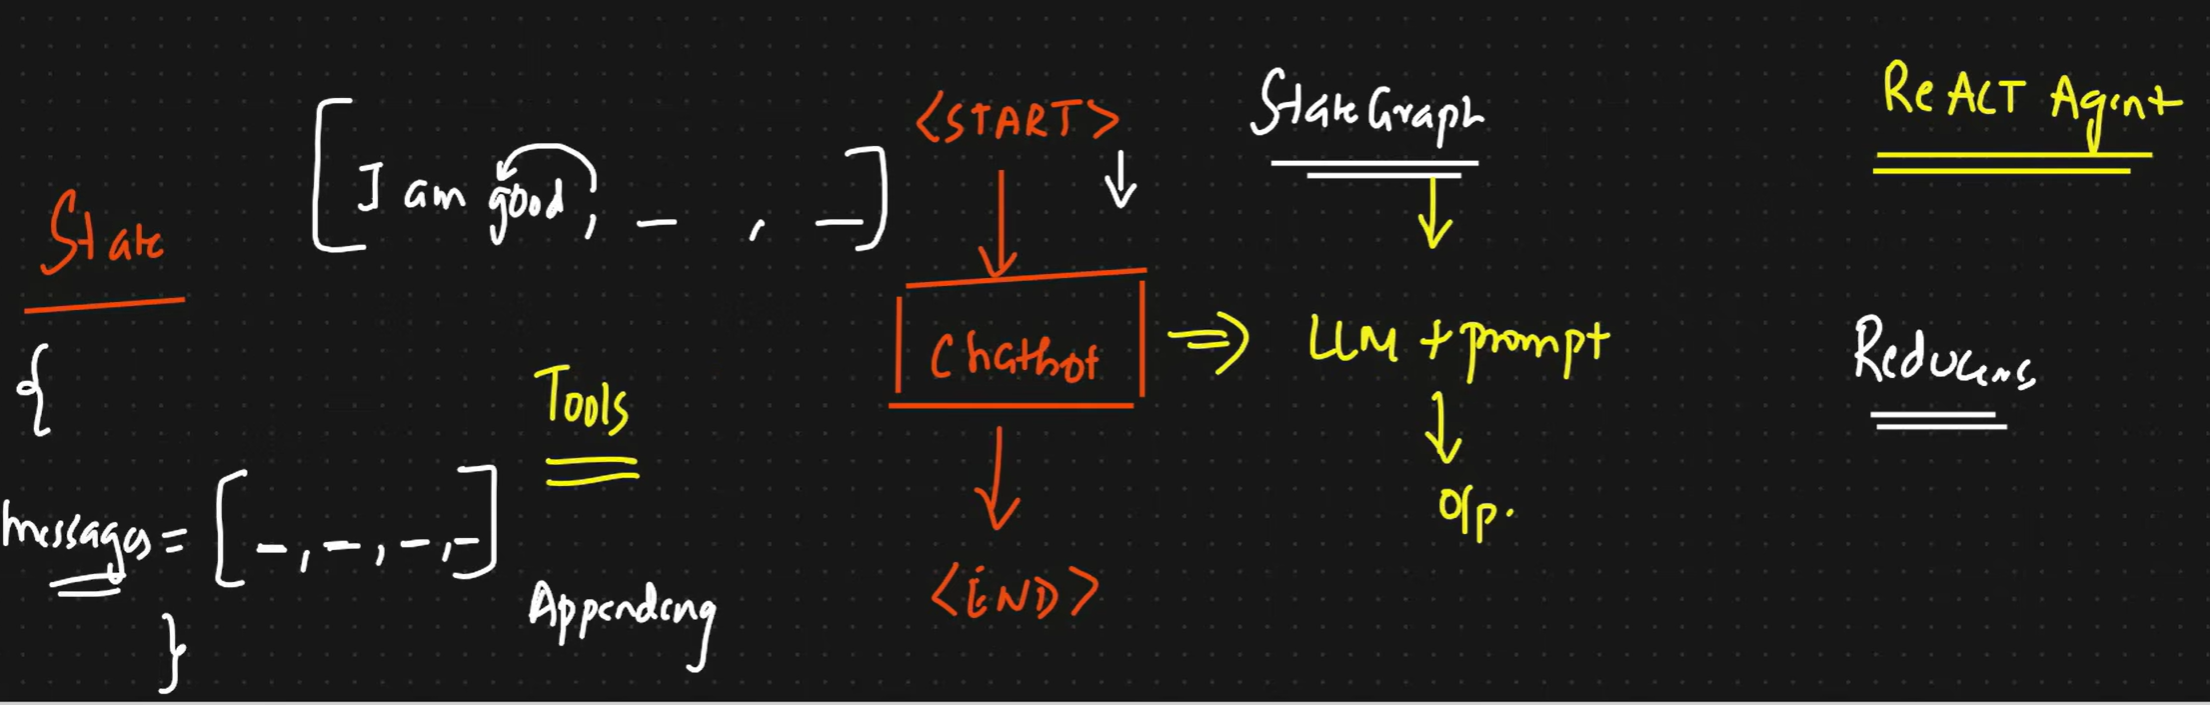

In [102]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model

load_dotenv()
llm= ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature= 0.5
)

llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 3.1 Flash Lite', 'release_date': '2026-05-07', 'last_updated': '2026-05-07', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.1-flash-lite', temperature=0.5, client=<google.genai.client.Client object at 0x0000012C30B86D70>, default_metadata=(), model_kwargs={})

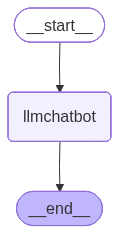

In [103]:
## Node Functionality
def chatbot(state:State):                
# Inheriting state from the 'State" Class, consider using State class as a 'state' variable only inside this function
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder= StateGraph(State)

## Adding Node
graph_builder.add_node("llmchatbot", chatbot)    # The middle single node

## Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## Compile the graph
graph= graph_builder.compile()
graph

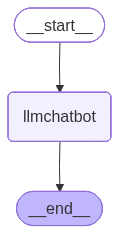

In [ ]:
## Visualization of Graph
from IPython.display import Image, display

try:
    display( Image( graph.get_graph().draw_mermaid_png() ) )
except Exception:
    print(ModuleNotFoundError, KeyError, IndexError, TypeError, AttributeError)

In [105]:
query= {"messages": [ "Tallest mountain", "HI, tell me how are you?" ]}
response = graph.invoke(query)
response

{'messages': [HumanMessage(content='Tallest mountain', additional_kwargs={}, response_metadata={}, id='76e1b390-85ed-4c36-84ee-a0621759af1d'),
  HumanMessage(content='HI, tell me how are you?', additional_kwargs={}, response_metadata={}, id='b6f4dbf1-54f0-410f-a604-c450b7f332e7'),
  AIMessage(content=[{'type': 'text', 'text': 'Hi there! I\'m doing great, thank you for asking! How are you doing today?\n\nTo answer your question about the tallest mountain:\n\n*   **Mount Everest** is the highest mountain above sea level, with its peak reaching **29,032 feet (8,849 meters)**. It is located in the Himalayas on the border between Nepal and China.\n\nHowever, depending on how you measure "tallest," there are two other contenders:\n\n*   **Mauna Kea:** If you measure from the base (which is on the ocean floor) to the peak, Mauna Kea in Hawaii is technically taller than Everest. It stands about **33,500 feet (10,210 meters)** from base to tip, though only 13,803 feet of it is above sea level.\

In [106]:
response["messages"][-1].content[0][    'text']

'Hi there! I\'m doing great, thank you for asking! How are you doing today?\n\nTo answer your question about the tallest mountain:\n\n*   **Mount Everest** is the highest mountain above sea level, with its peak reaching **29,032 feet (8,849 meters)**. It is located in the Himalayas on the border between Nepal and China.\n\nHowever, depending on how you measure "tallest," there are two other contenders:\n\n*   **Mauna Kea:** If you measure from the base (which is on the ocean floor) to the peak, Mauna Kea in Hawaii is technically taller than Everest. It stands about **33,500 feet (10,210 meters)** from base to tip, though only 13,803 feet of it is above sea level.\n*   **Mount Chimborazo:** If you measure from the center of the Earth, the summit of Mount Chimborazo in Ecuador is the farthest point from the Earth\'s core. This is because the Earth bulges at the equator, and Chimborazo sits nearly on that bulge.\n\nDo you have a favorite mountain, or were you just curious about the record

### **Streaming Graph Outputs**


In [107]:
graph.invoke({"messages": "Tallest mountain"})

{'messages': [HumanMessage(content='Tallest mountain', additional_kwargs={}, response_metadata={}, id='b3d6dd03-0fec-403a-8bb7-f71cef02dabb'),
  AIMessage(content=[{'type': 'text', 'text': 'The answer depends on how you define "tallest":\n\n*   **Highest altitude (above sea level):** **Mount Everest** is the tallest mountain in the world when measured from sea level. Its peak is **29,032 feet (8,849 meters)** above sea level. It is located in the Himalayas on the border between Nepal and China.\n\n*   **Tallest from base to peak:** **Mauna Kea**, a dormant volcano in Hawaii, is technically the tallest mountain from base to peak. Its base sits on the ocean floor; when measured from its underwater base to its peak, it stands about **33,500 feet (10,210 meters)** tall. However, only 13,803 feet of it is above sea level.\n\n*   **Closest to space (farthest from Earth\'s center):** **Mount Chimborazo** in Ecuador is the point on Earth closest to the stars. Because the Earth bulges at the eq

In [108]:
## graph.stream() returns a pointer which is handled by the unpacking operator '*' , graph.invoke() doesn't
print( *(graph.stream( query )), "\n" )     # Output by the node "llmchatbot"

for event in graph.stream(query):
    for value in event.values():
        for val in value.values():
            print(val[0].content)
        # OR
        # print(value["messages"][0].content) 
    ## OR
    print(event["llmchatbot"]["messages"][0].content[0]["text"])
    
value

{'llmchatbot': {'messages': [AIMessage(content=[{'type': 'text', 'text': "I'm doing great, thank you for asking! How are you doing today?\n\nTo answer your question about the tallest mountain:\n\n*   **Above sea level:** The tallest mountain on Earth is **Mount Everest**, which stands at 29,032 feet (8,849 meters) above sea level. It is located in the Himalayas on the border between Nepal and China.\n*   **From base to peak:** If you measure from the very bottom of the base to the top, **Mauna Kea** in Hawaii is actually the tallest. Its base sits on the ocean floor, and it measures about 33,500 feet (10,210 meters) from base to peak, though only 13,803 feet of it is above sea level.\n\nAre you interested in mountain climbing, or just curious about geography?", 'extras': {'signature': 'EjQKMgEMOdbHH+WqJD59MLAjUraQDTn1ApDN6BJKp54cKAMHdhAUtGhDbxNeMqHYGQtLmUrs'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': []

{'messages': [AIMessage(content=[{'type': 'text', 'text': "Hi there! I'm doing great, thank you for asking! How are you doing today?\n\nTo answer your question about the tallest mountain:\n\n*   **Above sea level:** The tallest mountain is **Mount Everest**, which stands at 29,032 feet (8,849 meters) above sea level.\n*   **From base to peak:** If you measure from the very bottom (the ocean floor) to the top, the tallest mountain is **Mauna Kea** in Hawaii. It stands about 33,500 feet (10,210 meters) tall, though only 13,803 feet of it are above sea level.\n\nAre you interested in mountains, or were you just curious?", 'extras': {'signature': 'EjQKMgEMOdbHXb6X/3Rjo+F+e94OaHbTTOqshnW722UltKl0VLQGMJWgHuSI4+yXUA7vHIFr'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb171-d371-7430-962a-30b3de9f77e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'

### **Chatbot with a Tool**

In [109]:
from langchain_tavily import TavilySearch
from pprint import pp

tool= TavilySearch( max_results= 4 )
response= tool.invoke("What is langgraph?")
pp(response)

count = len(response["results"])
print("No. of Urls searched: ",count)

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
              'title': 'What is LangGraph? - IBM',
              'content': 'LangGraph, created by LangChain, is an open source '
                         'AI agent framework designed to build, deploy and '
                         'manage complex generative AI agent workflows. It '
                         'provides a set of tools and libraries that enable '
                         'users to create, run and optimize large language '
                         'models (LLMs) in a scalable and efficient manner. At '
                         'its core, LangGraph uses the power of graph-based '
                         'architectures to model and manage the intricate '
                         'relationships between various components of an AI '
                         'agent workflow. The following example can offer a '
         

### Improving Structure using prettyprint

**Note:** 
We cant use the direct list comprehension for loop in the print() function but we can use it in the pp() 
and, we cant use the sep in the pp() but we can use it in the print()

In [110]:
# print( *(response["results"][i]["content"] for i in (0,count-1)), sep="\n\n---\n\n" )
## OR
from pprint import pp
pp( [f"{i+1}.{response['results'][i]['content']}" for i in range(count)], width=170)    # if custom prints, then use tuples: for i in (0,1,3)
# Note: If using f-strings as double quotes" then use the inner indexing using the single quotes

['1.LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set '
 'of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the '
 'power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer '
 'a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as '
 'being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigator charts out the optimal routes '
 'between points on the “Super-Map,” all of which are created by “The Cartographer.”. By combining these technologies with a set of APIs and tools, LangGr

In [111]:
## OR
from tavily import TavilyClient
import os
from dotenv import load_dotenv
load_dotenv()

client = TavilyClient()              # Automatically detects TAVILY_API_KEY using load_dotenv()
response = client.search(
    query="Tallest mountain in the world",
    search_depth="advanced"
)
pp(response)

{'query': 'Tallest mountain in the world',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/List_of_highest_mountains_on_Earth',
              'title': 'List of highest mountains on Earth - Wikipedia',
              'content': 'The bases of mountain islands are below sea level, '
                         'and given this consideration. Mauna Kea (4,207 m '
                         "(13,802 ft) above sea level) is the world's tallest "
                         'mountain and volcano, rising about 10,203 m (33,474 '
                         'ft) from the Pacific Ocean floor. Mount Lamlam on '
                         "Guam is periodically claimed to be among the world's "
                         'highest mountains because it is adjacent to the '
                         'Mariana Trench; the most extreme claim is that, '
                         'measured from Challenger Deep 313 kilometres (194 '
                         'mi

In [112]:
response['results'][0]['content']

"The bases of mountain islands are below sea level, and given this consideration. Mauna Kea (4,207 m (13,802 ft) above sea level) is the world's tallest mountain and volcano, rising about 10,203 m (33,474 ft) from the Pacific Ocean floor. Mount Lamlam on Guam is periodically claimed to be among the world's highest mountains because it is adjacent to the Mariana Trench; the most extreme claim is that, measured from Challenger Deep 313 kilometres (194 mi) away, Mount Lamlam is 11,530 metres (37,820 ft) tall. Ojos del Salado has the greatest rise on Earth: 13,420 m (44,029 ft) vertically to the summit[citation needed] from the bottom of the Atacama Trench, which is about 560 km (350 mi) away, although most of this rise is not part of the mountain. [...] The highest mountains above sea level are generally not the highest mountains above the surrounding terrain, also called the highest free-standing mountains. There is no precise definition of surrounding base, but Denali, Mount Kilimanjaro

### **ReACT Agent Basics**

In [113]:
## Custom Tool Function
def multiply(a:int, b:int)->int:
    # DocString
    """Multiply a and b
    Args :
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [ ]:
tools= [ tool, multiply ]     # List of all tools: TavilySearch() and custom multiply function
tools

[TavilySearch(max_results=4, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)),
 <function __main__.multiply(a: int, b: int) -> int>]

In [115]:
llm_with_tool= llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 3.1 Flash Lite', 'release_date': '2026-05-07', 'last_updated': '2026-05-07', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.1-flash-lite', temperature=0.5, client=<google.genai.client.Client object at 0x0000012C30B86D70>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, a

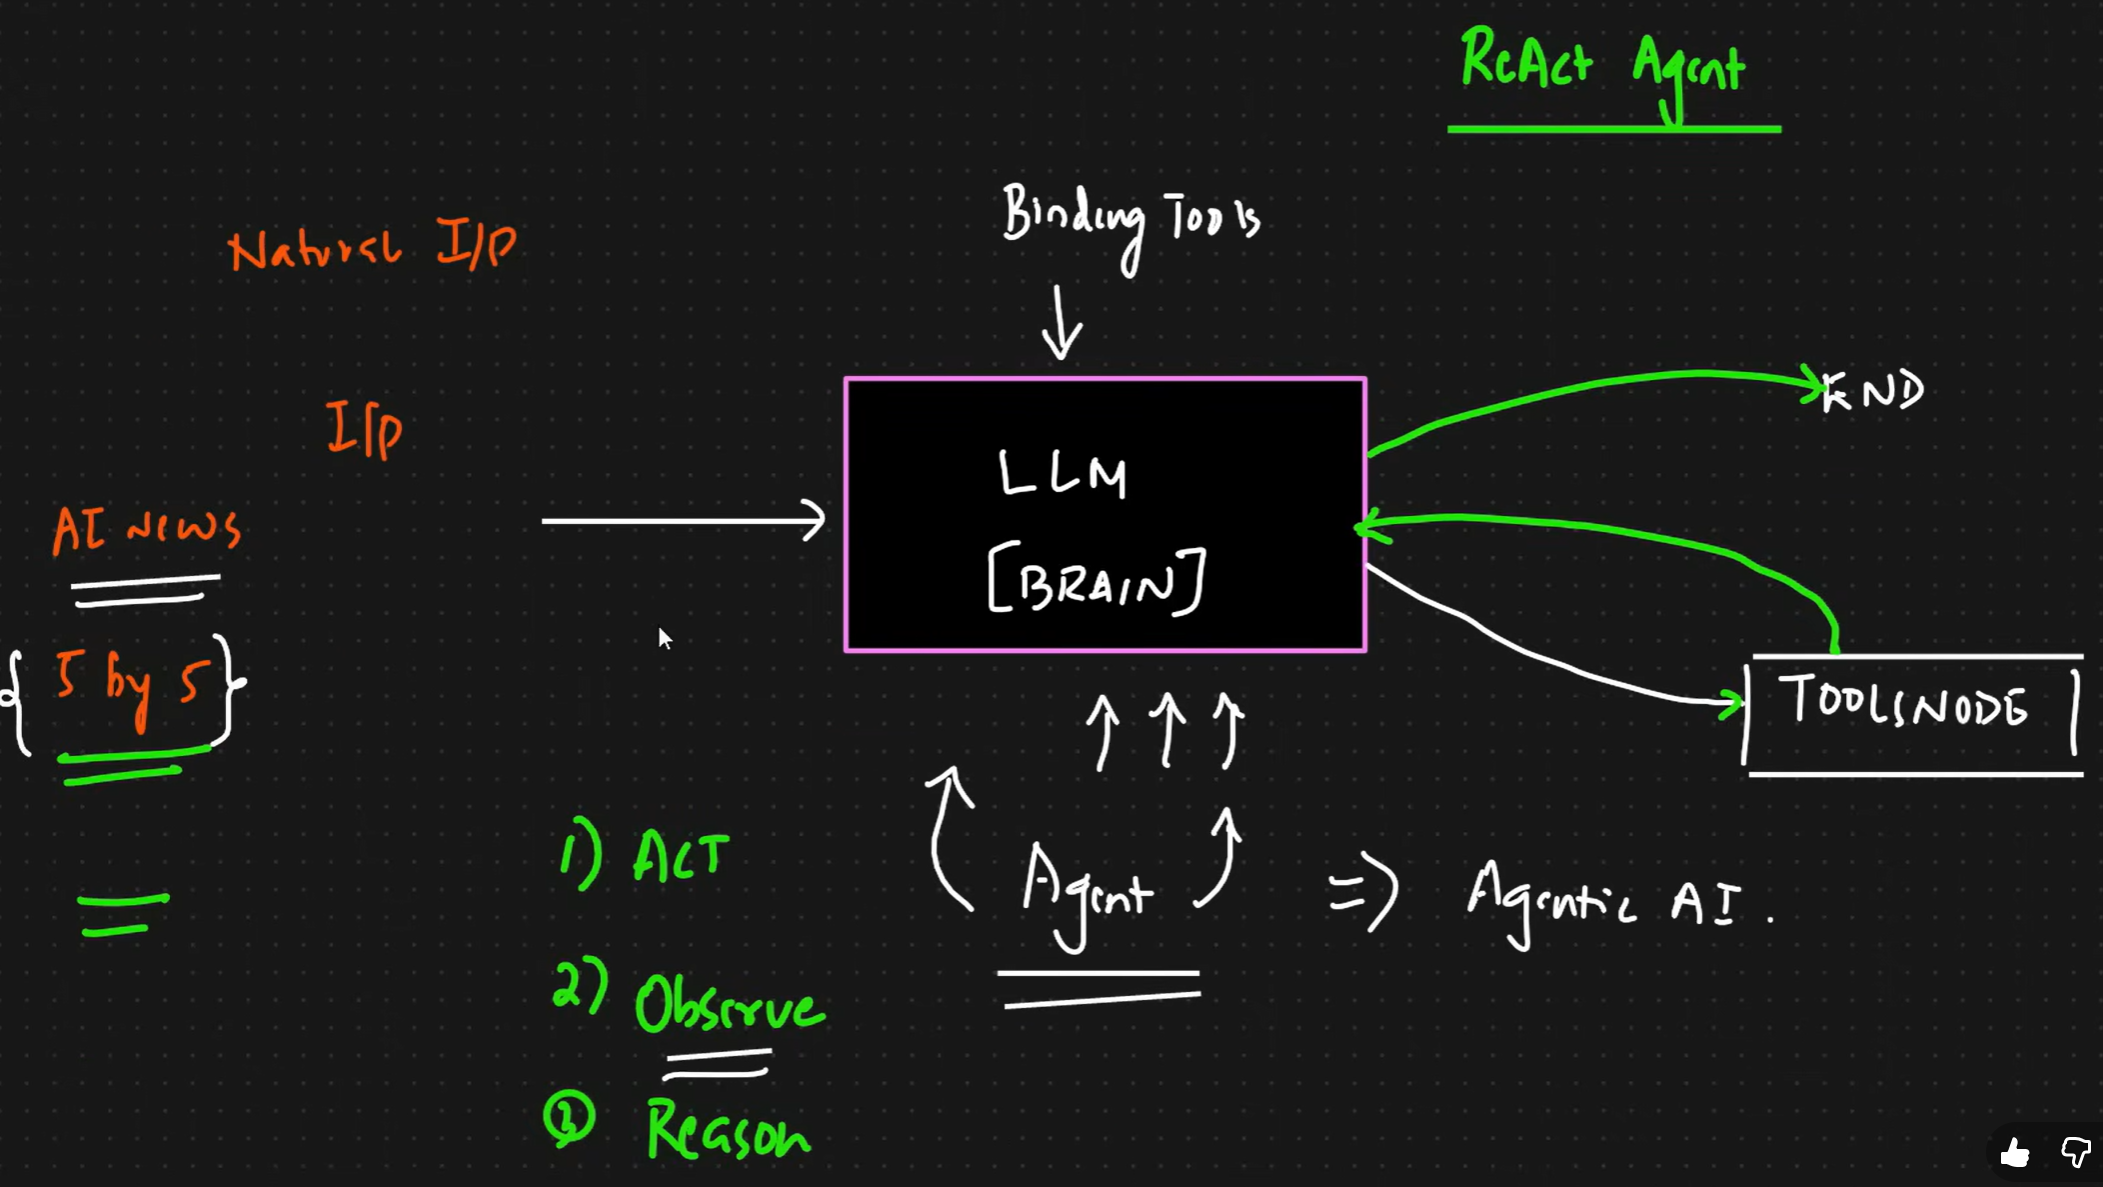

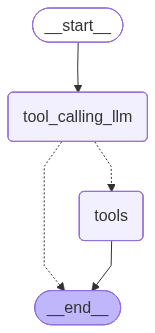

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

## Node function
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph Initialization and Nodes Creation
builder= StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)               ## ( "NAME_str", function )
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
# Disadvantage: This is only one-time call and no looping on tools can be applied.
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [117]:
response=graph.invoke({"messages":"What is the recent ai news"})
response['messages'][-1].content

'{"query": "recent AI news October 2024", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ipsos.com/en-us/artificial-intelligence-key-insights-data-and-tables", "title": "Artificial Intelligence: Key insights, data and tables - Ipsos", "content": "How social listening can inform better research and development — October 17, 2024; Fewer think AI is coming for white collar jobs — October 4, 2024; Gen AI", "score": 0.81979275, "raw_content": null}, {"url": "https://www.facebook.com/WIONews/posts/wionworlddna-ai-kills-tech-jobs-healthcare-fills-gapus-labor-market-hits-histori/1363542155884955", "title": "AI kills tech jobs, healthcare fills gap US labor market hits historic ...", "content": "The figure represents a 175% increase from the 55,000 cuts reported in October 2024, October saw an estimated 42,500 positions eliminated, contributing to a", "score": 0.79196626, "raw_content": null}, {"url": "https://guides.masslibsystem.org/ai/aihour", "ti

In [118]:
# pretty_print() is specifically designed for Langchain objects, so it wont work on other datastructures, so for general python use pp()

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (kZp2Fo3j)
 Call ID: kZp2Fo3j
  Args:
    time_range: month
    query: recent AI news October 2024
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news October 2024", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ipsos.com/en-us/artificial-intelligence-key-insights-data-and-tables", "title": "Artificial Intelligence: Key insights, data and tables - Ipsos", "content": "How social listening can inform better research and development — October 17, 2024; Fewer think AI is coming for white collar jobs — October 4, 2024; Gen AI", "score": 0.81979275, "raw_content": null}, {"url": "https://www.facebook.com/WIONews/posts/wionworlddna-ai-kills-tech-jobs-heal

In [119]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (xNG6cGln)
 Call ID: xNG6cGln
  Args:
    b: 2
    a: 5
================================= Tool Message =================================
Name: multiply

10


### **ReAct Agent Architecture**: Looping over Tools

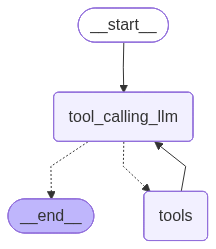

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")      # Looping

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [121]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (R0hlBWxo)
 Call ID: R0hlBWxo
  Args:
    query: recent AI news
    time_range: week
  multiply (kxmOLVuP)
 Call ID: kxmOLVuP
  Args:
    b: 10
    a: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-may-2026", "title": "The latest AI news we announced in May 2026", "content": "Google's May 2026 updates center on the new \"agentic\" era, featuring the Gemini 3.5 model and Gemini Omni for advanced reasoning and creation.", "score": 0.77261686, "raw_content": null}, {"url": "https://www.bbc.co.uk/news/topics/ce1qrvl

### **Adding Memory in Agentic Graph**

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory= MemorySaver()

## LLM Function
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder= StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph= builder.compile(checkpointer= memory)

In [123]:
config= { "configurable" : {"thread_id": "1"} }      ## Creates a Session with a unique session_id/thread_id

In [124]:
response= graph.invoke(
    {"messages": "My name is Ratish"}, 
    config= config
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

My name is Ratish
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hello, Ratish! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHXus9yccCTrG52flQfu+yi6GZzKTOMZu2CKvWpCn/Q3QQd7S46+qpJJHpa7ZG'}}]


### **It now remembers old conversations**

In [125]:
response= graph.invoke(
    {
        "messages": "What's my name?",
    },
    config= config
)
response["messages"][-1].content[0]['text']

'Your name is Ratish.'

## **Streaming**
#### Methods: .stream() and .astream()
#### . These methods are sync and async methods for streaming back results.
#### Additional parameters in streaming modes for graph state:
##### - values : This streams the full state of the graph after each node is called.
##### - updates : This streams updates to the state of the graph after each node is called.

In [126]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

memory= MemorySaver()

In [ ]:
## LLM Function
def superbot(state:State):
    return {"messages": [llm.invoke(state['messages'])]}

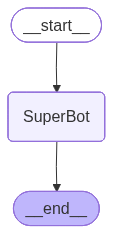

In [128]:
graph= StateGraph(State)

graph.add_node("SuperBot", superbot)

graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder= graph.compile(checkpointer= memory)

graph_builder

In [129]:
config= { "configurable": {"thread_id": "4"} }

response= graph_builder.invoke(                    # Normal Invoking 
    {
        "messages": "Hi! WASUUPP??"
    },
    config=config
)
response

{'messages': [HumanMessage(content='Hi! WASUUPP??', additional_kwargs={}, response_metadata={}, id='adaa627d-5605-4c42-aaaf-5a1f16883f15'),
  AIMessage(content=[{'type': 'text', 'text': "WASSUP!! Not much, just hanging out in the digital void, ready to help you with whatever you need. \n\nHow are things going with you? What's on your mind today?", 'extras': {'signature': 'EjQKMgEMOdbHaJZIjXliXUmoVfVWWzrQnfWzdPQmjZE+gbqSdJCCrHGgbp5+bLUw4ujfKppo'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb172-e68f-7871-a9f6-d65d1dce7b82-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 41, 'total_tokens': 49, 'input_token_details': {'cache_read': 0}})]}

#### 1. Updates: Streaming Current AIMessage only

In [ ]:
query={"messages": "My name's Ratish!!"}
# Streaming with Memory
for chunk in graph_builder.stream( query, config, stream_mode="updates" ):
    pp(chunk['SuperBot']['messages'][0].content[0]['text'], width=130)

## Alternative to stream a chunk: Lambda Function
# get_text= lambda x: x['SuperBot']['messages'][0].content[0]['text']      # Can use global variable instead of SuperBot
# pp(get_text(chunk), width=150

## OR
# Define lambda with a default 'node' parameter
# get_text = lambda x, node="SuperBot": x[node]['messages'][0].content[0]['text']

# Usage 1: Uses the default ("SuperBot")
# pp(get_text(chunk), width=130)

# Usage 2: Overrides default for a different node if specified (e.g., "tool_calling_llm")
# pp(get_text(chunk, node="tool_calling_llm"), width=130)

("Got it, **Ratish**! I promise I won't forget it. \n"
 '\n'
 'Since we’ve got that officially locked in, what’s on your mind today? Are you looking to chat, learn something, or do you have '
 "a project you're working on?")



#### 2. Values: Appending at the end
2 Outputs: Previous Output and Current O/p= Current O/p + Previous O/p ( Holds the conversation about the entire session)

In [ ]:
# config= { "configurable": {"thread_id": "3"} }
query={"messages": ["What's my Name again?"]}
for chunk in graph_builder.stream(query, config, stream_mode="values"):            # QCS: query, config and stream_mode
    pp(chunk, width=130)

{'messages': [HumanMessage(content='Hi! WASUUPP??', additional_kwargs={}, response_metadata={}, id='36cc3043-bd2a-4068-bf0d-714a2a850ad2'),
              AIMessage(content=[{'type': 'text', 'text': "WASSUP!! Not much, just hanging out in the digital void, ready to help you with whatever you need. \n\nHow are things going with you? What's on your mind today?", 'extras': {'signature': 'EjQKMgEMOdbHElQltglzT5m7bbJF59qxYdF0mpYc4kFt3s/YKcl+1c8zwtAGgnLxIjoNa9eY'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb15b-7ef3-7383-b3e8-128bce8b4e73-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 41, 'total_tokens': 49, 'input_token_details': {'cache_read': 0}}),
              HumanMessage(content="My name's Ratish!!", additional_kwargs={}, response_metadata={}, id='7dede445-c505-4373-acd7-a122c10e98bc'),
              AIM

#### Async, Astream: For more Extra Analysis

In [ ]:
async for event in graph_builder.astream_events( query, config, version= 'v2' ):
    pp(event)

{'event': 'on_chain_start',
 'data': {'input': {'messages': ["What's my Name again?"]}},
 'name': 'LangGraph',
 'tags': [],
 'run_id': '019eb15b-86ee-7e30-86c8-db434df40fa9',
 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'},
 'parent_ids': []}
{'event': 'on_chain_start',
 'data': {'input': {'messages': [HumanMessage(content='Hi! WASUUPP??', additional_kwargs={}, response_metadata={}, id='36cc3043-bd2a-4068-bf0d-714a2a850ad2'),
                                 AIMessage(content=[{'type': 'text', 'text': "WASSUP!! Not much, just hanging out in the digital void, ready to help you with whatever you need. \n\nHow are things going with you? What's on your mind today?", 'extras': {'signature': 'EjQKMgEMOdbHElQltglzT5m7bbJF59qxYdF0mpYc4kFt3s/YKcl+1c8zwtAGgnLxIjoNa9eY'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb15b-7ef3-7383-b3e8-128bce8b4e73-

### **Human In The Loop (HITL)**
**Final Complete Chatbot with Human Assistance Tool and Tavily Tool, Memory and HITL(Interruption)**

In [ ]:
import os
from langchain.chat_models import init_chat_model

llm=init_chat_model("google_genai:gemini-2.5-flash-lite")
llm

ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash-Lite', 'release_date': '2025-06-17', 'last_updated': '2025-06-17', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash-lite', client=<google.genai.client.Client object at 0x0000012C30B84C30>, default_metadata=(), model_kwargs={})

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

from langgraph.types import Command, interrupt

## Step-1: Class Creation
class State(TypedDict):
    messages: Annotated[list, add_messages]

load_dotenv()
llm= ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature= 0.5
)

graph_builder = StateGraph(State)

## Step-2: Tool Node Creation with Interrupt, And Initialization/Binding with LLM
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})     # Waiting/Paused
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

## Step-3: LLM Node Creation
def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    return {"messages": [message]}

## Step-4: Graph Flow Creation
graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)            # OR graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")

In [ ]:
## Step-5: Adding Memory to the Agent and Graph Compilation 
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

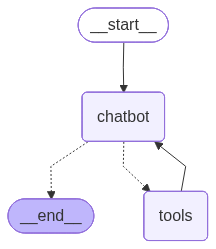

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
## Step-6: Streaming through a Session with Memory, modes = values/updates
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
pp(events)

print("\n")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

# OR directly use QCS graph.stream method in for loop

<generator object Pregel.stream at 0x0000012C2FAB0190>


================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (10ded778-a7f8-430e-95eb-c5827cf6b821)
 Call ID: 10ded778-a7f8-430e-95eb-c5827cf6b821
  Args:
    query: I need some expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (10ded778-a7f8-430e-95eb-c5827cf6b821)
 Call ID: 10ded778-a7f8-430e-95eb-c5827cf6b821
  Args:
    query: I need some expert guidance and assistance for building an AI agent.


interrupt(): When the LLM decides it needs expert help, it calls the human_assistance tool. Inside this tool, interrupt() is called.
The Pause: The interrupt function immediately pauses the graph execution and saves the state to memory (using the compiled MemorySaver checkpointer). The program exits the stream, waiting for external human input.

Command(resume=...): This tells LangGraph to look at the active checkpoint on the current thread_id and resume execution. The dictionary {"data": human_response} is fed back into the graph as the return value of the interrupt() function that was waiting in Step 2.}

In [ ]:
## Step-7: Using Human Intervention using Command to resume the pause by Interrupt
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})    # Giving (here, predefined) human input to resume the interrupt's pause 
print(human_command)

events = graph.stream(human_command, config, stream_mode="values")      # CCS: Command, Config, Stream_modes
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

Command(resume={'data': "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents."})
================================== Ai Message ==================================
Tool Calls:
  human_assistance (10ded778-a7f8-430e-95eb-c5827cf6b821)
 Call ID: 10ded778-a7f8-430e-95eb-c5827cf6b821
  Args:
    query: I need some expert guidance and assistance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================


### **Real World Scenarios**

1. **Financial Transactions (Approval Gate)**
   * **Scenario:** Pausing before executing a `send_wire_transfer(amount=5000)` tool call.
   * **HITL Flow:** Graph interrupts -> Manager reviews -> Sends `Command(resume="Approve")` to release the funds.

2. **Content Moderation (Review & Edit)**
   * **Scenario:** Pausing before calling `post_to_twitter(draft_text)`.
   * **HITL Flow:** Graph interrupts -> Specialist reviews/edits typo -> Sends `Command(resume=corrected_text)`.

3. **Collecting Missing Data (User Input)**
   * **Scenario:** Pausing mid-workflow during flight booking because the passport number is missing.
   * **HITL Flow:** Graph interrupts -> User enters passport number -> Sends `Command(resume=passport_num)` to resume booking.

### **Flow: Make a State Class (add messages Reducer)-> Call a llm -> Make a tool like Tavily Search ->  Combine all tools (in-built, custom function) into a list-> Integrate the list into llm using bind_tools -> Create a State Graph (Use conditional edges) and compile it with MemorySaver() -> Invoke or Stream the graph using stream_modes and config sessions-> Create HITL Middleware using Interrupts (in tool node) and Command(resume={})**

## **Model Cotnext Protocol(MCP)**

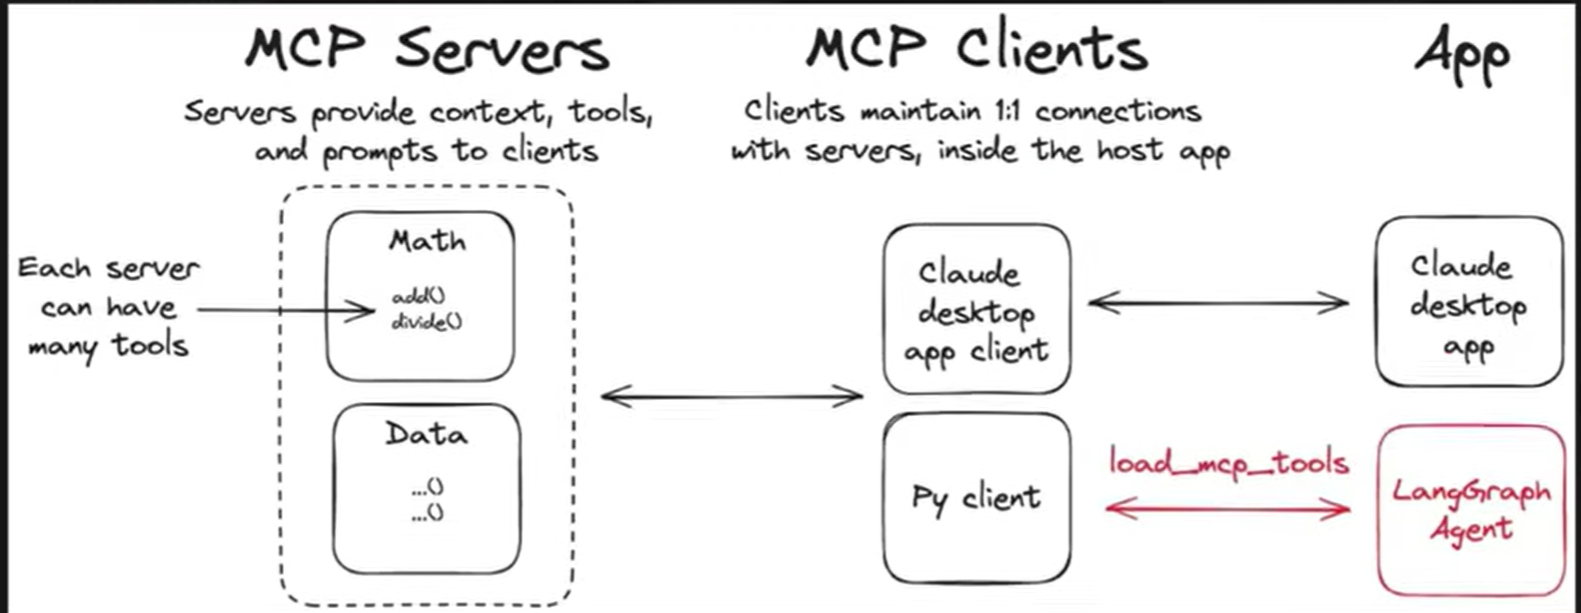

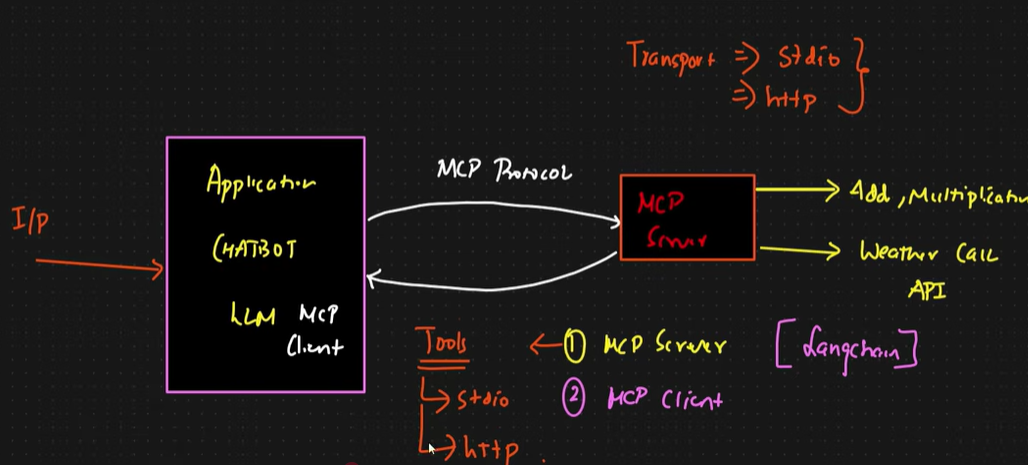